Train shape: (750, 8), Test shape: (150, 8)
Windowed Train shape: (147, 112), Windowed Test shape: (27, 112)
Random Forest Test Accuracy: 0.6667

Random Forest Classification Report:
              precision    recall  f1-score   support

         Sit       0.69      1.00      0.82         9
       Stand       0.56      0.56      0.56         9
        Walk       0.80      0.44      0.57         9

    accuracy                           0.67        27
   macro avg       0.68      0.67      0.65        27
weighted avg       0.68      0.67      0.65        27



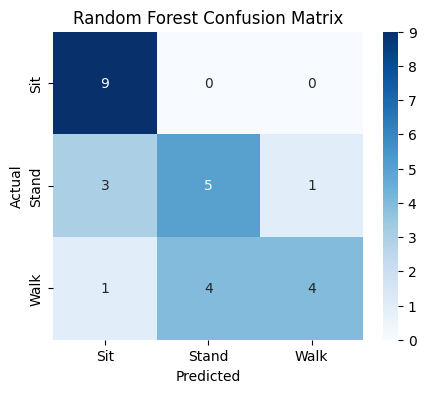

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,683 (92.51 KB)

 Trainable params: 23,299 (91.01 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
4/4 - 3s - 661ms/step - accuracy: 0.4274 - loss: 1.3132 - val_accuracy: 0.6000 - val_loss: 0.9315 - learning_rate: 1.0000e-03
Epoch 2/100
4/4 - 0s - 24ms/step - accuracy: 0.6581 - loss: 0.8277 - val_accuracy: 0.6667 - val_loss: 0.8395 - learning_rate: 1.0000e-03
Epoch 3/100
4/4 - 0s - 34ms/step - accuracy: 0.6923 - loss: 0.8084 - val_accuracy: 0.6667 - val_loss: 0.7715 - learning_rate: 1.0000e-03
Epoch 4/100
4/4 - 0s - 74ms/step - accuracy: 0.7607 - loss: 0.7017 - val_accuracy: 0.7000 - val_loss: 0.7162 - learning_rate: 1.0000e-03
Epoch 5/100
4/4 - 0s - 73ms/step - accuracy: 0.8205 - loss: 0.4722 - val_accuracy: 0.7000 - val_loss: 0.6771 - learning_rate: 1.0000e-03
Epoch 6/100
4/4 - 0s - 81ms/step - accuracy: 0.8291 - loss: 0.3847 - val_accuracy: 0.7333 - val_loss: 0.6526 - learning_rate: 1.0000e-03
Epoch 7/100
4/4 - 0s - 34ms/step - accuracy: 0.8974 - loss: 0.4252 - val_accuracy: 0.7333 - val_loss: 0.6347 - learning_rate: 1.0000e-03
Epoch 8/100
4/4 - 0s - 41ms/step - accur

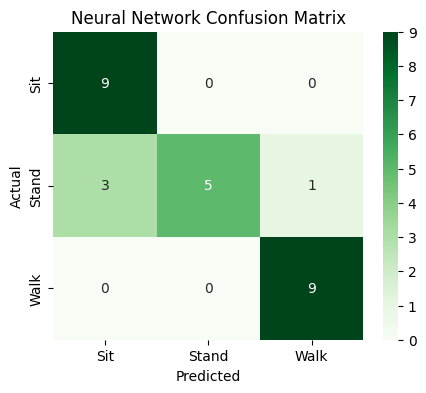

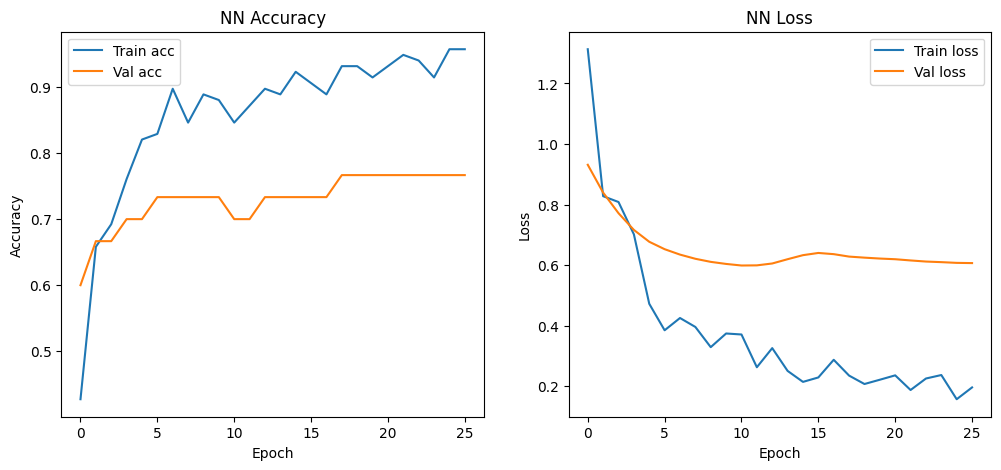

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ------- STEP 1: Data Loading and Parsing --------

def parse_raw_bytes(raw_bytes_str):
    """Parse the raw bytes string into a list of integers."""
    bytes_list = []
    for b in raw_bytes_str.strip().split():
        try:
            # Handle hex or decimal numbers, though your CSV is decimal
            if b.lower().startswith('0x'):
                val = int(b, 16)
            else:
                val = int(b)
            bytes_list.append(val)
        except:
            bytes_list.append(0)
    return bytes_list

def to_signed_int(val):
    """Convert unsigned byte to signed int8"""
    return val - 256 if val >= 128 else val

def extract_features_from_row(raw_bytes_str, start=4, end=12):
    """Extract signed int features from bytes 4 to 11 inclusive."""
    full_bytes = parse_raw_bytes(raw_bytes_str)
    if len(full_bytes) < end:
        # pad with zeros if too short
        full_bytes += [0] * (end - len(full_bytes))
    slice_bytes = full_bytes[start:end]
    signed_bytes = [to_signed_int(b) for b in slice_bytes]
    return signed_bytes  # list of length 8

def load_and_process_file(csv_file, label):
    """Load CSV, parse raw bytes into numeric features, and assign label."""
    df = pd.read_csv(csv_file)
    X = np.array([extract_features_from_row(rb) for rb in df['Raw_Bytes']])
    y = np.full(len(df), label)
    return X, y

# Load data for all activities
X_sit, y_sit = load_and_process_file('sit train.csv', 0)
X_stand, y_stand = load_and_process_file('stand train.csv', 1)
X_walk, y_walk = load_and_process_file('walk train.csv', 2)

X_sit_test, y_sit_test = load_and_process_file('sit test.csv', 0)
X_stand_test, y_stand_test = load_and_process_file('stand test.csv', 1)
X_walk_test, y_walk_test = load_and_process_file('walk test.csv', 2)

# Combine training and test data
X_train_full = np.vstack([X_sit, X_stand, X_walk])
y_train_full = np.concatenate([y_sit, y_stand, y_walk])

X_test = np.vstack([X_sit_test, X_stand_test, X_walk_test])
y_test = np.concatenate([y_sit_test, y_stand_test, y_walk_test])

print(f"Train shape: {X_train_full.shape}, Test shape: {X_test.shape}")

# ------- STEP 2: Feature Engineering with Sliding Windows ---------

def sliding_window_feature_extraction(X, y, window_size=10, step=5):
    """
    Create sliding windows from sequential data.
    For each window:
      - concatenate raw bytes for each row in window
      - add stats: mean, std, min, max for each byte position over window
    """
    X_new = []
    y_new = []
    for start_idx in range(0, len(X) - window_size + 1, step):
        end_idx = start_idx + window_size
        window_x = X[start_idx:end_idx]
        window_y = y[start_idx:end_idx]

        # Ensure all labels in window are the same (avoid mixed windows)
        if np.unique(window_y).size != 1:
            continue

        # Raw concatenated bytes: shape (window_size * 8)
        raw_concat = window_x.flatten()

        # Stats per byte position over window
        mean_vals = window_x.mean(axis=0)
        std_vals = window_x.std(axis=0)
        min_vals = window_x.min(axis=0)
        max_vals = window_x.max(axis=0)

        # Feature vector
        features = np.concatenate([raw_concat, mean_vals, std_vals, min_vals, max_vals])

        X_new.append(features)
        y_new.append(window_y[0])

    X_new = np.array(X_new)
    y_new = np.array(y_new)
    return X_new, y_new

# Extract sliding window features from training and test sets
WINDOW_SIZE = 10
STEP = 5

X_train, y_train = sliding_window_feature_extraction(X_train_full, y_train_full, WINDOW_SIZE, STEP)
X_test_windows, y_test_windows = sliding_window_feature_extraction(X_test, y_test, WINDOW_SIZE, STEP)

print(f"Windowed Train shape: {X_train.shape}, Windowed Test shape: {X_test_windows.shape}")

# ------- STEP 3: Data Scaling --------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test_windows)

# ------- STEP 4: Model Training -------

# Option 1: Random Forest Classifier (strong baseline for tabular data)
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test_windows, y_pred_rf)
print(f"Random Forest Test Accuracy: {acc_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test_windows, y_pred_rf, target_names=['Sit', 'Stand', 'Walk']))

# Confusion Matrix RF
cm_rf = confusion_matrix(y_test_windows, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sit', 'Stand', 'Walk'],
            yticklabels=['Sit', 'Stand', 'Walk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# ------- Option 2: Neural Network (MLP) for comparison --------

import tensorflow as tf

NUM_CLASSES = 3

# One-hot encoding for labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test_windows, NUM_CLASSES)

# Define MLP model
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=7, factor=0.5)

# Train-validation split
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_scaled, y_train_cat, test_size=0.2, stratify=y_train, random_state=42
)

history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

# Evaluate
loss, acc_nn = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Neural Network Test Accuracy: {acc_nn:.4f}")

# Predictions
y_pred_nn = model.predict(X_test_scaled).argmax(axis=1)

print("\nNeural Network Classification Report:")
print(classification_report(y_test_windows, y_pred_nn, target_names=['Sit', 'Stand', 'Walk']))

# Confusion Matrix NN
cm_nn = confusion_matrix(y_test_windows, y_pred_nn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sit', 'Stand', 'Walk'],
            yticklabels=['Sit', 'Stand', 'Walk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()

# ------- Optional: Plot training history --------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('NN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('NN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
